In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [3]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

In [6]:
df.shape

(41188, 21)

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [11]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(12)

In [13]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

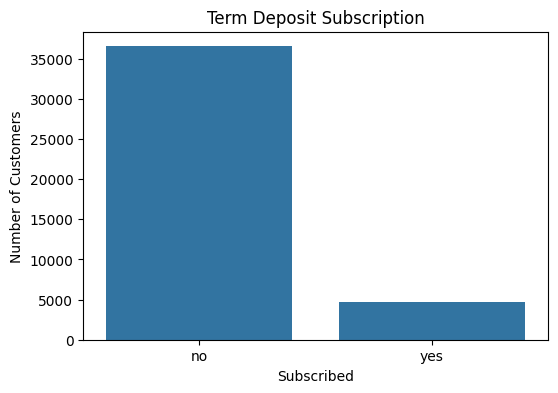

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Term Deposit Subscription")
plt.xlabel("Subscribed")
plt.ylabel("Number of Customers")
plt.show()

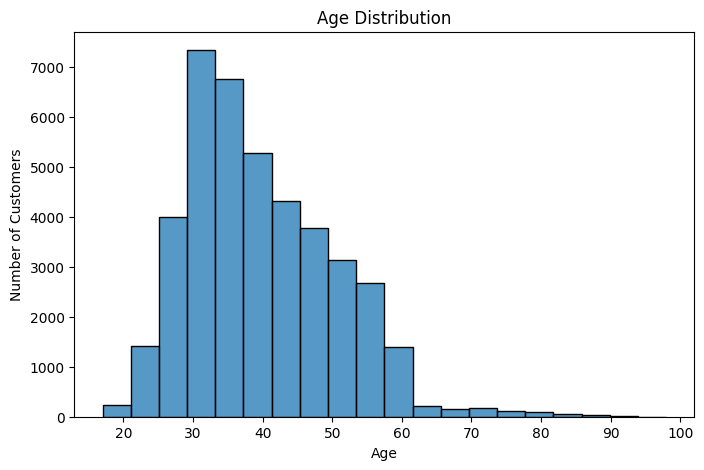

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

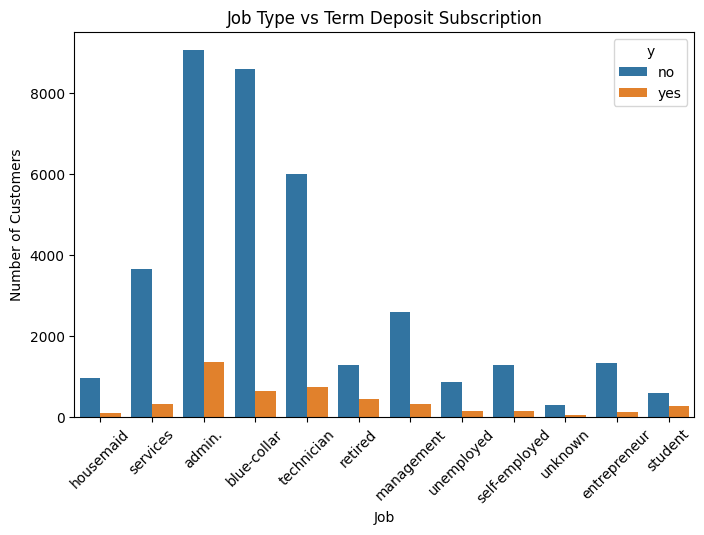

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="job", hue="y")
plt.title("Job Type vs Term Deposit Subscription")
plt.xticks(rotation=45)
plt.xlabel("Job")
plt.ylabel("Number of Customers")
plt.show()

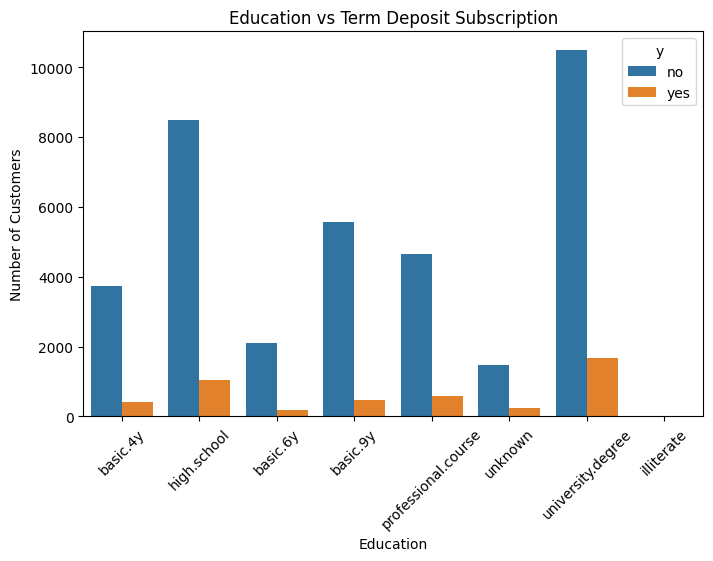

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="education", hue="y")
plt.title("Education vs Term Deposit Subscription")
plt.xticks(rotation=45)
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.show()

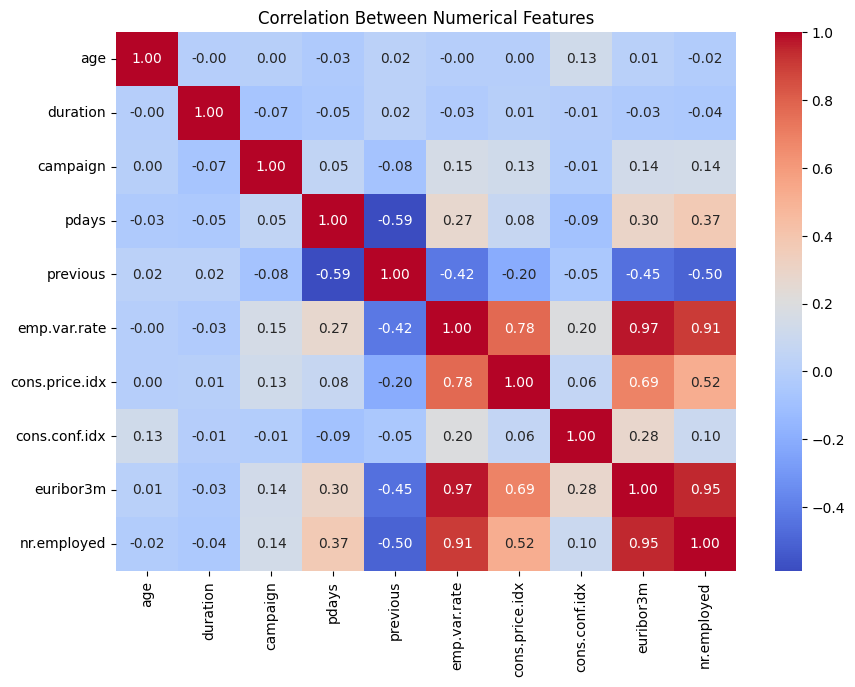

In [18]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Numerical Features")
plt.show()

In [ ]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (41176, 21)


In [20]:
X = df.drop("y", axis=1)
y = df["y"]
print("Features:", X.shape)
print("Target:", y.shape)

Features: (41176, 20)
Target: (41176,)


In [21]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing created successfully!")

Preprocessing created successfully!


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (32940, 20)
Testing data: (8236, 20)


In [24]:
model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(max_iter=1000)
    )
])

print("Model created successfully!")

Model created successfully!


In [25]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [26]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions completed!
First 10 predictions:
['no' 'yes' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no']


In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9095434677027683

Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.97      0.95      7308
         yes       0.65      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.79      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236



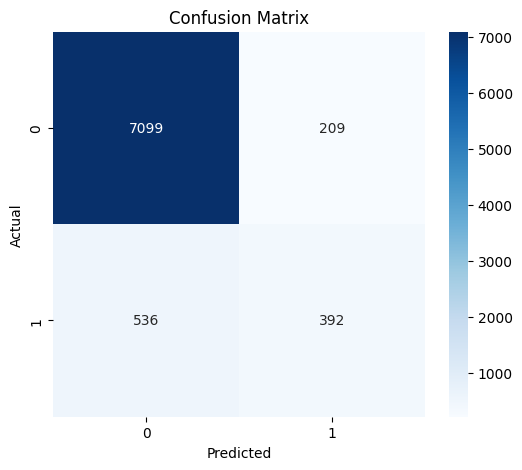

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
joblib.dump(model, "bank_model.pkl")

print("Model saved successfully as bank_model.pkl")

Model saved successfully as bank_model.pkl


In [37]:
# Calculate all evaluation results
accuracy = accuracy_score(y_test, y_pred)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

precision = report["yes"]["precision"]
recall = report["yes"]["recall"]
f1 = report["yes"]["f1-score"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["no", "yes"]
)

In [39]:
y_test_binary = (y_test == "yes").astype(int)

y_probability = model.predict_proba(
    X_test
)[:, list(model.classes_).index("yes")]
roc_auc = roc_auc_score(y_test_binary, y_probability)

In [40]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

feature_names = (
    preprocessor
    .get_feature_names_out()
)

coefficients = classifier.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(coefficients),
    "Coefficient": coefficients
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [44]:
results = {

    "accuracy": accuracy,

    "precision": precision,

    "recall": recall,

    "f1": f1,

    "roc_auc": roc_auc,

    "confusion_matrix": cm,

    "fpr": fpr,

    "tpr": tpr,

    "feature_importance": feature_importance,

    "classification_report": report
}


joblib.dump(
    results,
    "bank_results.pkl"
)


print("\nModel saved as bank_model.pkl")
print("Results saved as bank_results.pkl")

print("\nFinal Model Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)


Model saved as bank_model.pkl
Results saved as bank_results.pkl

Final Model Results:
Accuracy: 0.9095434677027683
Precision: 0.6522462562396006
Recall: 0.4224137931034483
F1 Score: 0.512753433616743
ROC-AUC: 0.938979837872525
